## Importaciones y configuración inicial

In [1]:
# IMPORTACIONES GENERALES

# Librerías estándar para rutas, fechas y utilidades generales
import os
import random
from pathlib import Path
from datetime import datetime

# Tratamiento de datos y operaciones numéricas
import numpy as np
import pandas as pd

# Visualización de resultados y gráficos
import matplotlib.pyplot as plt

# Carga y reproducción de audio en el cuaderno
import librosa
from IPython.display import Audio as IPythonAudio, display

# Datasets de Hugging Face
from datasets import load_from_disk, Audio

# Métricas de evaluación para transcripción
import evaluate

# PyTorch para ejecutar los modelos en CPU o GPU
import torch

# Componentes de Whisper para cargar modelos, procesadores y generar predicciones
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    GenerationConfig,
    set_seed
)

# Barra de progreso para procesos largos
from tqdm.auto import tqdm

In [48]:
# CONFIGURACIÓN GENERAL

SEED = 42

RUTA_BASE_AUDIOS = Path(r"C:\Lara\audios-230426\audios-s3")

RUTA_DATASET_ORIGINAL = Path(r"C:\Lara\datasets\lara_whisper_dataset")
RUTA_DATASET_PREPARADO = Path(r"C:\Lara\datasets\lara_whisper_dataset_preparado")

RUTA_MODELO_INICIAL = Path(r"C:\Lara\modelos_entrenados\whisper_base")
RUTA_MODELO_MEJORADO = Path(r"C:\Lara\modelos_entrenados\whisper_base_mejorado")

RUTA_RESULTADOS = Path(r"C:\Lara\resultados\04_analisis_errores_modelo_mejorado")
RUTA_RESULTADOS.mkdir(parents=True, exist_ok=True)

ARCHIVO_COMPARATIVA = RUTA_RESULTADOS / "comparativa_modelo_inicial_vs_mejorado.csv"

N_MUESTRAS_ANALISIS = None  # Usar None para analizar todo el test

## Carga del dataset de test

In [8]:
# CARGA DEL DATASET PREPARADO

dataset_preparado = load_from_disk(str(RUTA_DATASET_PREPARADO))

print(dataset_preparado)
print("Columnas:", dataset_preparado.column_names)
print("Número total de muestras:", len(dataset_preparado))

Loading dataset from disk:   0%|          | 0/79 [00:00<?, ?it/s]

Dataset({
    features: ['input_features', 'labels'],
    num_rows: 40842
})
Columnas: ['input_features', 'labels']
Número total de muestras: 40842


In [9]:
# RECONSTRUCCIÓN DE SPLITS TRAIN / TEST / EVAL

set_seed(SEED)

# Se reconstruye la misma división usada en los cuadernos anteriores
split_inicial = dataset_preparado.train_test_split(
    test_size=0.2,
    seed=SEED
)

dataset_train = split_inicial["train"]
dataset_temporal = split_inicial["test"]

# Del 20% temporal se obtiene el test y la evaluación final
split_temporal = dataset_temporal.train_test_split(
    test_size=0.2,
    seed=SEED
)

dataset_test = split_temporal["train"]
dataset_eval = split_temporal["test"]

print("Train:", len(dataset_train))
print("Test:", len(dataset_test))
print("Eval:", len(dataset_eval))
print("Columnas test:", dataset_test.column_names)

Train: 32673
Test: 6535
Eval: 1634
Columnas test: ['input_features', 'labels']


## Carga de modelos y procesadores

In [10]:
# CARGA DE MODELOS Y PROCESADORES

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Dispositivo utilizado:", device)

# Cargamos el modelo inicial entrenado en el cuaderno 02
processor_inicial = WhisperProcessor.from_pretrained(str(RUTA_MODELO_INICIAL))
modelo_inicial = WhisperForConditionalGeneration.from_pretrained(str(RUTA_MODELO_INICIAL)).to(device)

# Cargamos el modelo mejorado entrenado en el cuaderno 03
processor_mejorado = WhisperProcessor.from_pretrained(str(RUTA_MODELO_MEJORADO))
modelo_mejorado = WhisperForConditionalGeneration.from_pretrained(str(RUTA_MODELO_MEJORADO)).to(device)

modelo_inicial.eval()
modelo_mejorado.eval()

print("Modelo inicial cargado desde:", RUTA_MODELO_INICIAL)
print("Modelo mejorado cargado desde:", RUTA_MODELO_MEJORADO)

Dispositivo utilizado: cuda


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Modelo inicial cargado desde: C:\Lara\modelos_entrenados\whisper_base
Modelo mejorado cargado desde: C:\Lara\modelos_entrenados\whisper_base_mejorado


In [11]:
# COMPROBACIÓN DE UNA MUESTRA DEL TEST

muestra = dataset_test[0]

texto_real = processor_mejorado.batch_decode(
    [muestra["labels"]],
    skip_special_tokens=True
)[0]

print("Texto real decodificado:")
print(texto_real)

print("\nForma de input_features:")
print(np.array(muestra["input_features"]).shape)

print("\nNúmero de tokens en labels:")
print(len(muestra["labels"]))

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Texto real decodificado:
EN LA LATA HAY LIMONADA.

Forma de input_features:
(80, 3000)

Número de tokens en labels:
16


## Generación de predicciones con ambos modelos

In [12]:
# FUNCIÓN PARA GENERAR PREDICCIONES

def generar_prediccion(input_features, modelo, processor):
    """
    Genera una transcripción a partir de las características de audio ya preparadas.
    """

    # Convertimos las features a tensor y añadimos la dimensión de batch
    input_tensor = torch.tensor(
        input_features,
        dtype=torch.float32
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        predicted_ids = modelo.generate(input_tensor)

    # Decodificamos los tokens generados a texto
    texto_predicho = processor.batch_decode(
        predicted_ids,
        skip_special_tokens=True
    )[0]

    return texto_predicho.strip()

In [13]:
# PRUEBA DE PREDICCIÓN CON UNA MUESTRA

muestra = dataset_test[0]

texto_real = processor_mejorado.batch_decode(
    [muestra["labels"]],
    skip_special_tokens=True
)[0].strip()

prediccion_inicial = generar_prediccion(
    muestra["input_features"],
    modelo_inicial,
    processor_inicial
)

prediccion_mejorada = generar_prediccion(
    muestra["input_features"],
    modelo_mejorado,
    processor_mejorado
)

print("Texto real:")
print(texto_real)

print("\nPredicción modelo inicial:")
print(prediccion_inicial)

print("\nPredicción modelo mejorado:")
print(prediccion_mejorada)

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
[transformers] A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transform

Texto real:
EN LA LATA HAY LIMONADA.

Predicción modelo inicial:
EN LA LATA HAY LIMONADA.

Predicción modelo mejorado:
EN LA LATA HAY LIMONADA.


In [14]:
# CARGA DE MÉTRICAS

metrica_wer = evaluate.load("wer")
metrica_cer = evaluate.load("cer")

print("Métricas cargadas correctamente")

Métricas cargadas correctamente


In [15]:
# GENERACIÓN DE PREDICCIONES Y CÁLCULO DE MÉTRICAS POR MUESTRA

resultados = []

indices = list(range(len(dataset_test)))

if N_MUESTRAS_ANALISIS is not None:
    indices = indices[:N_MUESTRAS_ANALISIS]

for indice in tqdm(indices, desc="Analizando muestras del test"):

    muestra = dataset_test[indice]

    # Recuperamos el texto real desde los labels
    texto_real = processor_mejorado.batch_decode(
        [muestra["labels"]],
        skip_special_tokens=True
    )[0].strip()

    # Generamos predicción con ambos modelos
    prediccion_inicial = generar_prediccion(
        muestra["input_features"],
        modelo_inicial,
        processor_inicial
    )

    prediccion_mejorada = generar_prediccion(
        muestra["input_features"],
        modelo_mejorado,
        processor_mejorado
    )

    # Calculamos métricas individuales
    wer_inicial = metrica_wer.compute(
        predictions=[prediccion_inicial],
        references=[texto_real]
    )

    wer_mejorado = metrica_wer.compute(
        predictions=[prediccion_mejorada],
        references=[texto_real]
    )

    cer_inicial = metrica_cer.compute(
        predictions=[prediccion_inicial],
        references=[texto_real]
    )

    cer_mejorado = metrica_cer.compute(
        predictions=[prediccion_mejorada],
        references=[texto_real]
    )

    resultados.append({
        "indice_test": indice,
        "texto_real": texto_real,
        "prediccion_modelo_inicial": prediccion_inicial,
        "prediccion_modelo_mejorado": prediccion_mejorada,
        "wer_inicial": wer_inicial,
        "wer_mejorado": wer_mejorado,
        "cer_inicial": cer_inicial,
        "cer_mejorado": cer_mejorado,
        "diferencia_wer": wer_inicial - wer_mejorado,
        "diferencia_cer": cer_inicial - cer_mejorado
    })

df_comparativa = pd.DataFrame(resultados)

df_comparativa.head()

Analizando muestras del test:   0%|          | 0/6535 [00:00<?, ?it/s]

,indice_test,texto_real,prediccion_modelo_inicial,prediccion_modelo_mejorado,wer_inicial,wer_mejorado,cer_inicial,cer_mejorado,diferencia_wer,diferencia_cer
0,0,EN LA LATA HAY LIMONADA.,EN LA LATA HAY LIMONADA.,EN LA LATA HAY LIMONADA.,0.0,0.0,0.000000,0.000000,0.0,0.0
1,1,ME ASOMARÉ DESDE EL DÉCIMO PISO.,ME ASOMARÉ DESDE EL DÉCIMO PISO.,ME ASOMARÉ DESDE EL DÉCIMO PISO.,0.0,0.0,0.000000,0.000000,0.0,0.0
2,2,AFRONTAR LA AFRENTA DE ALFREDO.,AFRONTAR LA AFRENTA DE ALFREDO.,AFRONTAR LA AFRENTA DE ALFREDO.,0.0,0.0,0.000000,0.000000,0.0,0.0
3,3,HOY TENGO QUE COGER EL BUS PARA IR A LA BIBLIO...,HOY TENGO QUE COGER EL BUS PARA IR A LA BIBLIO...,HOY TENGO QUE COGER EL BUS PARA IR A LA BIBLIO...,0.0,0.0,0.000000,0.000000,0.0,0.0
4,4,EL CIELO ES CALIDO,EL GRIEGO DE PELO GRIS TIENE GRIPA.,EL GRIEGO DE PELO GRIS TIENE GRIPA.,1.5,1.5,1.333333,1.333333,0.0,0.0


In [16]:
# GUARDADO DE LA COMPARATIVA

df_comparativa.to_csv(
    ARCHIVO_COMPARATIVA,
    index=False,
    encoding="utf-8-sig"
)

print("Comparativa guardada en:")
print(ARCHIVO_COMPARATIVA)

Comparativa guardada en:
C:\Lara\resultados\04_analisis_errores_modelo_mejorado\comparativa_modelo_inicial_vs_mejorado.csv


## Resumen general de la comparativa

In [17]:
# RESUMEN GENERAL DE MÉTRICAS

resumen_metricas = pd.DataFrame({
    "modelo": ["Inicial", "Mejorado"],
    "wer_medio": [
        df_comparativa["wer_inicial"].mean(),
        df_comparativa["wer_mejorado"].mean()
    ],
    "cer_medio": [
        df_comparativa["cer_inicial"].mean(),
        df_comparativa["cer_mejorado"].mean()
    ],
    "wer_mediana": [
        df_comparativa["wer_inicial"].median(),
        df_comparativa["wer_mejorado"].median()
    ],
    "cer_mediana": [
        df_comparativa["cer_inicial"].median(),
        df_comparativa["cer_mejorado"].median()
    ],
    "wer_maximo": [
        df_comparativa["wer_inicial"].max(),
        df_comparativa["wer_mejorado"].max()
    ],
    "cer_maximo": [
        df_comparativa["cer_inicial"].max(),
        df_comparativa["cer_mejorado"].max()
    ]
})

resumen_metricas

,modelo,wer_medio,cer_medio,wer_mediana,cer_mediana,wer_maximo,cer_maximo
0,Inicial,0.597070,0.442408,0.384615,0.241379,37.50,32.518519
1,Mejorado,0.496674,0.359453,0.000000,0.000000,7.25,9.357143


In [18]:
# DIFERENCIA GLOBAL ENTRE MODELOS

wer_inicial_medio = df_comparativa["wer_inicial"].mean()
wer_mejorado_medio = df_comparativa["wer_mejorado"].mean()

cer_inicial_medio = df_comparativa["cer_inicial"].mean()
cer_mejorado_medio = df_comparativa["cer_mejorado"].mean()

mejora_wer = wer_inicial_medio - wer_mejorado_medio
mejora_cer = cer_inicial_medio - cer_mejorado_medio

porcentaje_mejora_wer = (mejora_wer / wer_inicial_medio) * 100
porcentaje_mejora_cer = (mejora_cer / cer_inicial_medio) * 100

print("WER inicial medio:", round(wer_inicial_medio, 4))
print("WER mejorado medio:", round(wer_mejorado_medio, 4))
print("Mejora absoluta WER:", round(mejora_wer, 4))
print("Mejora relativa WER:", round(porcentaje_mejora_wer, 2), "%")

print("\nCER inicial medio:", round(cer_inicial_medio, 4))
print("CER mejorado medio:", round(cer_mejorado_medio, 4))
print("Mejora absoluta CER:", round(mejora_cer, 4))
print("Mejora relativa CER:", round(porcentaje_mejora_cer, 2), "%")

WER inicial medio: 0.5971
WER mejorado medio: 0.4967
Mejora absoluta WER: 0.1004
Mejora relativa WER: 16.81 %

CER inicial medio: 0.4424
CER mejorado medio: 0.3595
Mejora absoluta CER: 0.083
Mejora relativa CER: 18.75 %


In [19]:
# CLASIFICACIÓN DE CADA MUESTRA SEGÚN LA EVOLUCIÓN DEL WER

def clasificar_resultado(fila):
    """
    Clasifica cada muestra según si el modelo mejorado reduce, aumenta o mantiene el WER.
    """

    if fila["wer_mejorado"] < fila["wer_inicial"]:
        return "Mejora"
    elif fila["wer_mejorado"] > fila["wer_inicial"]:
        return "Empeora"
    else:
        return "Igual"

df_comparativa["resultado_comparacion"] = df_comparativa.apply(
    clasificar_resultado,
    axis=1
)

df_comparativa["resultado_comparacion"].value_counts()

resultado_comparacion
Igual      3515
Mejora     1812
Empeora    1208
Name: count, dtype: int64

                       muestras  porcentaje
resultado_comparacion                      
Igual                      3515       53.79
Mejora                     1812       27.73
Empeora                    1208       18.49


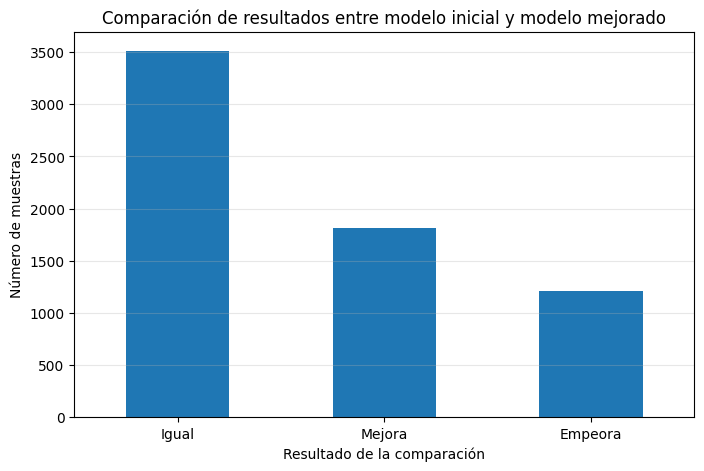

In [23]:
# RESUMEN DE MUESTRAS MEJORADAS, EMPEORADAS O IGUALES

conteo_resultados = df_comparativa["resultado_comparacion"].value_counts()
porcentaje_resultados = df_comparativa["resultado_comparacion"].value_counts(normalize=True) * 100

df_resumen_resultados = pd.DataFrame({
    "muestras": conteo_resultados,
    "porcentaje": porcentaje_resultados.round(2)
})

print(df_resumen_resultados)    

# GRÁFICO DE DISTRIBUCIÓN DE RESULTADOS

df_resumen_resultados["muestras"].plot(kind="bar", figsize=(8, 5))

plt.title("Comparación de resultados entre modelo inicial y modelo mejorado")
plt.xlabel("Resultado de la comparación")
plt.ylabel("Número de muestras")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

#### Casos donde más mejora el modelo

In [24]:
# CASOS DONDE MÁS MEJORA EL MODELO

df_mayores_mejoras = df_comparativa.sort_values(
    by="diferencia_wer",
    ascending=False
).head(20)

df_mayores_mejoras[
    [
        "indice_test",
        "texto_real",
        "prediccion_modelo_inicial",
        "prediccion_modelo_mejorado",
        "wer_inicial",
        "wer_mejorado",
        "cer_inicial",
        "cer_mejorado",
        "diferencia_wer",
        "diferencia_cer"
    ]
]

,indice_test,texto_real,prediccion_modelo_inicial,prediccion_modelo_mejorado,wer_inicial,wer_mejorado,cer_inicial,cer_mejorado,diferencia_wer,diferencia_cer
3370,3370,SE AGRADECE TU ALEGRÍA.,TEA LA TELENO QUE PESA PESA PESA PESA PESA PES...,SE AGRADE PARA TELÉFONOS POR LA REGIONE DE PAR...,37.500000,2.500000,31.826087,1.956522,35.000000,29.869565
270,270,AL CRUZAR EL PUENTE ME CRUJIERON LOS HUESOS DE...,LA FUENTE DE LA FUENTE ME COMPRA LA FUENTE DE ...,EL PANTALÓN DE PANA ES DE PANA Y ANTE MONTÓN.,26.500000,1.000000,20.345455,0.763636,25.500000,19.581818
4544,4544,JUGAMOS AL PARCHÍS CON FICHAS.,¡JUANJO ES EL JEFE CORTANDO SALTANDO PORTANDO ...,JUGAMOS AL CLUEDO CON CLIMA.,22.600000,0.400000,29.166667,0.400000,22.200000,28.766667
2086,2086,MI HIJA ES UNA GRAN FANÁTICA DE LOS POSTRES Y ...,ME ENCANTA IR AL PARQUE T T T T T T T T T T T ...,ME ENCANTA IR A LA VERDULERÍA Y COMPRAR PRENDI...,19.130435,0.913043,7.040984,0.778689,18.217391,6.262295
4926,4926,RECLAMAN CICLOS FORMATIVOS DE RECICLAJE.,LOS MÁS TREPITAN TREPITAN TREPITAN TREPITAN TR...,ROMÁN SIEMPRE VA A COMER A LA SUREÑA.,18.000000,1.600000,19.425000,0.800000,16.400000,18.625000
6501,6501,AL RECIBIR EL DIPLOMA LE DIERON MUCHOS APLAUSOS.,ESTUVE EN LA CIMA DE CIMA PORQUE NO LLEVÓ EL C...,EL TIFÓN LLEGÓ AL GOLF TODOS LOS GARABATOS.,15.250000,1.000000,10.875000,0.687500,14.250000,10.187500
126,126,MI ABUELA SIEMPRE ME ENSEÑA A PREPARAR PLATOS ...,IREMOS A LA PANTERA EN LA PANTERA EN LA PANTER...,MI ABUELO SE LME ABRAÑOSA DE COMERCIALES DE LUZ.,9.666667,0.833333,10.670886,0.582278,8.833333,10.088608
5600,5600,COLOCAME,¡CORRO! QUE CANCIÓN MÁS COCHINA,COLOCAME,5.000000,0.000000,3.125000,0.000000,5.000000,3.125000
4741,4741,JUANI TRADUJO TODO.,¡CORRER! QUE TE TE PORQUE NO LLEGAMOS A LA CAR...,JUANI TRADUJO TODO.,3.333333,0.000000,2.263158,0.000000,3.333333,2.263158
2225,2225,JUAN BARAJA CARTAS,¡JUANBA! QUE TE TE PASO LOS PESAS DE TANTA.,JUAN BARAJA CARTAS,3.000000,0.000000,1.777778,0.000000,3.000000,1.777778


#### Casos done más empeora el modelo

In [25]:
# CASOS DONDE MÁS EMPEORA EL MODELO

df_mayores_empeoramientos = df_comparativa.sort_values(
    by="diferencia_wer",
    ascending=True
).head(20)

df_mayores_empeoramientos[
    [
        "indice_test",
        "texto_real",
        "prediccion_modelo_inicial",
        "prediccion_modelo_mejorado",
        "wer_inicial",
        "wer_mejorado",
        "cer_inicial",
        "cer_mejorado",
        "diferencia_wer",
        "diferencia_cer"
    ]
]

,indice_test,texto_real,prediccion_modelo_inicial,prediccion_modelo_mejorado,wer_inicial,wer_mejorado,cer_inicial,cer_mejorado,diferencia_wer,diferencia_cer
156,156,CUANDO LEO REFLEXIONO.,CUANDO LEO REFLEXIONO.,"CON EL CRITERIO DE ESTA REYES, ME CRUDO QUE EL...",0.000,4.000000,0.000000,2.136364,-4.000000,-2.136364
1339,1339,NO SE OYE BIEN,"VICENTE AL MONTAR DE LAS BOTELLAS DE CINE, SE ...",ME LLAMÓ YESICA A LA MI HERMANA IR A RESTAURAN...,3.750,7.250000,5.000000,9.357143,-3.500000,-4.357143
1648,1648,SARA SABE MUCHO,SARA SABE MUCHO,SALTÉ A LA COMIDA CON MI SALADO MUY SALTÍA.,0.000,3.000000,0.000000,2.266667,-3.000000,-2.266667
5796,5796,AQUÍ LLUEVE POCO.,AQUÍ LLUEVE POCO.,EL SUPLEMENTO DEL PERIÓN ES MUY COMPLEADO.,0.000,2.333333,0.000000,1.941176,-2.333333,-1.941176
5373,5373,FRANCISCA TIENE FRIO.,SANCIANA TIENE EL SILLO,SACÓ SU TRACTOR PARA TRAER EL TRANVÍA A EL TRA...,1.000,3.333333,0.523810,1.904762,-2.333333,-1.380952
4622,4622,HABÍA UNA UVA,HABÍA UNA UVA,COMÍ A UN DRUIDO CON DRÁSTICO.,0.000,2.000000,0.000000,1.846154,-2.000000,-1.846154
2433,2433,ELENA ELIGE ROPA,ELENA ELIGE ROPA,ELENA HABLÓ CON PABLO DE LA BIBLIOTECA.,0.000,2.000000,0.000000,1.750000,-2.000000,-1.750000
6191,6191,ELENA ELIGE ROPA,ELENA ELIGE ROPA,ELENA HABLÓ CON PABLO DE LA BIBLIA.,0.000,2.000000,0.000000,1.562500,-2.000000,-1.562500
5402,5402,EL GUSANO COME GUISANTES.,EL GUSANO COME GUISANTES.,EN OTOÑO COMO UN PIANO DE POCHA SIETE.,0.000,2.000000,0.000000,1.040000,-2.000000,-1.040000
5422,5422,PILAR COME POCO.,PILAR COME POCO.,PILIAR SE SENTÓ EN LA COL.,0.000,2.000000,0.000000,0.937500,-2.000000,-0.937500


#### Errores graves del modelo mejorado

In [26]:
# ERRORES GRAVES DEL MODELO MEJORADO

UMBRAL_WER_GRAVE = 0.75
UMBRAL_CER_GRAVE = 0.75

df_errores_graves_mejorado = df_comparativa[
    (df_comparativa["wer_mejorado"] >= UMBRAL_WER_GRAVE) |
    (df_comparativa["cer_mejorado"] >= UMBRAL_CER_GRAVE)
].sort_values(
    by=["wer_mejorado", "cer_mejorado"],
    ascending=False
)

print("Número de errores graves en el modelo mejorado:", len(df_errores_graves_mejorado))

df_errores_graves_mejorado[
    [
        "indice_test",
        "texto_real",
        "prediccion_modelo_inicial",
        "prediccion_modelo_mejorado",
        "wer_inicial",
        "wer_mejorado",
        "cer_inicial",
        "cer_mejorado"
    ]
].head(20)

Número de errores graves en el modelo mejorado: 2441


,indice_test,texto_real,prediccion_modelo_inicial,prediccion_modelo_mejorado,wer_inicial,wer_mejorado,cer_inicial,cer_mejorado
1339,1339,NO SE OYE BIEN,"VICENTE AL MONTAR DE LAS BOTELLAS DE CINE, SE ...",ME LLAMÓ YESICA A LA MI HERMANA IR A RESTAURAN...,3.750000,7.250000,5.000000,9.357143
2001,2001,Hola,EL HAZ DE LUZ ASUSTÓ AL RAPAZ.,O HAGAS FUEGO JUNTO AL LAGO.,7.000000,6.000000,7.250000,6.750000
2389,2389,COLOCAME,¡CORRO HE IDO AL CORREO!,"CORRER Y GANAR, TODO ES EMPEZAR.",5.000000,6.000000,2.375000,3.375000
156,156,CUANDO LEO REFLEXIONO.,CUANDO LEO REFLEXIONO.,"CON EL CRITERIO DE ESTA REYES, ME CRUDO QUE EL...",0.000000,4.000000,0.000000,2.136364
4462,4462,JUAN BARAJA CARTAS,LA CICATRIZ DE CEMENTO ES DE LA C CICLA.,LA CICATRIZ DE MI MANO IZQUIERA SE GUARDA PARA...,3.000000,3.333333,1.833333,2.333333
2127,2127,JUAN BARAJA CARTAS,LE HARÉ UN REFRÁN A AFRODITA.,LE HARÉ UN REFRÁN A AFLARER LA FATIÓN DE MFRAN...,2.000000,3.333333,1.111111,2.222222
4873,4873,ELENA ELIGE ROPA,LA LEÑA SE GUARDA EN LA LEÑERA Y NO LLEVARÁ A ...,LA LEÑA SE GUARDA EN LA LEÑERA CON MI MOCHE.,4.333333,3.333333,2.875000,2.187500
5373,5373,FRANCISCA TIENE FRIO.,SANCIANA TIENE EL SILLO,SACÓ SU TRACTOR PARA TRAER EL TRANVÍA A EL TRA...,1.000000,3.333333,0.523810,1.904762
1665,1665,QUIERO APRENDER IDIOMAS.,EN MI COLEGIO HAY PALOMAS.,QUIERE QUE EL SER EN EL CAMPO EN EL LÍTICO.,1.666667,3.333333,0.750000,1.250000
4604,4604,ESTE ALCOHOL HUELE MAL.,AQUEL CRIMINAL ERA CRETINO Y CRÁPULA.,EL EQUIPO DE ATLETISMO DE MI ESCUELA GANÓ EL C...,1.500000,3.250000,1.260870,2.521739


In [27]:
# GUARDADO DE RESÚMENES DEL ANÁLISIS

ARCHIVO_RESUMEN_METRICAS = RUTA_RESULTADOS / "resumen_metricas_modelo_inicial_vs_mejorado.csv"
ARCHIVO_RESUMEN_RESULTADOS = RUTA_RESULTADOS / "resumen_muestras_mejora_empeora_igual.csv"

resumen_metricas.to_csv(
    ARCHIVO_RESUMEN_METRICAS,
    index=False,
    encoding="utf-8-sig"
)

df_resumen_resultados.to_csv(
    ARCHIVO_RESUMEN_RESULTADOS,
    index=True,
    encoding="utf-8-sig"
)

print("Resumen de métricas guardado en:")
print(ARCHIVO_RESUMEN_METRICAS)

print("\nResumen de clasificación guardado en:")
print(ARCHIVO_RESUMEN_RESULTADOS)

Resumen de métricas guardado en:
C:\Lara\resultados\04_analisis_errores_modelo_mejorado\resumen_metricas_modelo_inicial_vs_mejorado.csv

Resumen de clasificación guardado en:
C:\Lara\resultados\04_analisis_errores_modelo_mejorado\resumen_muestras_mejora_empeora_igual.csv


#### Errores corregidos completamente

In [28]:
# ERRORES CORREGIDOS COMPLETAMENTE POR EL MODELO MEJORADO

df_errores_corregidos = df_comparativa[
    (df_comparativa["wer_inicial"] > 0) &
    (df_comparativa["wer_mejorado"] == 0)
].sort_values(
    by="wer_inicial",
    ascending=False
)

print("Número de errores corregidos completamente:", len(df_errores_corregidos))

df_errores_corregidos[
    [
        "indice_test",
        "texto_real",
        "prediccion_modelo_inicial",
        "prediccion_modelo_mejorado",
        "wer_inicial",
        "wer_mejorado",
        "cer_inicial",
        "cer_mejorado"
    ]
].head(20)

Número de errores corregidos completamente: 856


,indice_test,texto_real,prediccion_modelo_inicial,prediccion_modelo_mejorado,wer_inicial,wer_mejorado,cer_inicial,cer_mejorado
5600,5600,COLOCAME,¡CORRO! QUE CANCIÓN MÁS COCHINA,COLOCAME,5.000000,0.0,3.125000,0.0
4741,4741,JUANI TRADUJO TODO.,¡CORRER! QUE TE TE PORQUE NO LLEGAMOS A LA CAR...,JUANI TRADUJO TODO.,3.333333,0.0,2.263158,0.0
2815,2815,MAÑANA COMO MANZANA,MARINA VA MUY BIEN EN EL PILOTE DE PINO.,MAÑANA COMO MANZANA,3.000000,0.0,1.631579,0.0
2225,2225,JUAN BARAJA CARTAS,¡JUANBA! QUE TE TE PASO LOS PESAS DE TANTA.,JUAN BARAJA CARTAS,3.000000,0.0,1.777778,0.0
6225,6225,ERES UN CRACK CRISTÓBAL.,ÉL SAPO DE SAMUEL ESTÁ SUFRIENDO EN LA ESTULE ...,ERES UN CRACK CRISTÓBAL.,2.750000,0.0,1.875000,0.0
2112,2112,APRIETA APRISA LA TUERCA.,A PILI LE APETECE VA LA PITUna LA PELA DE PHANO.,APRIETA APRISA LA TUERCA.,2.500000,0.0,1.280000,0.0
5657,5657,LA SOPA ESTABA SUPER SALADA,EL SUFLÉ ME SALIÓ DE CHUFA EL SFLÉ ME SALIÓ DE...,LA SOPA ESTABA SUPER SALADA,2.400000,0.0,32.518519,0.0
6161,6161,LA MUCHACHA SUFRIÓ UNA AVALANCHA.,LOS MOFLETES DE CANTINFLAS SON DE CHUFLA Y CHU...,LA MUCHACHA SUFRIÓ UNA AVALANCHA.,2.400000,0.0,1.363636,0.0
2688,2688,"SÉ INGLÉS, JAPONÉS Y PORTUGUÉS",SEÑORES JAZ LLEVAN MU toro cuando vayas a la T...,"SÉ INGLÉS, JAPONÉS Y PORTUGUÉS",2.400000,0.0,1.733333,0.0
2249,2249,BRENO GASTA BROMAS.,EL DROMOMÁTICO ES DROMÁTICO DE EL DROMÓN.,BRENO GASTA BROMAS.,2.333333,0.0,1.684211,0.0


#### Aciertos del modelo inicial que el modelo mejorado empeora

In [29]:
# ACIERTOS DEL MODELO INICIAL QUE EMPEORAN EN EL MODELO MEJORADO

df_aciertos_empeorados = df_comparativa[
    (df_comparativa["wer_inicial"] == 0) &
    (df_comparativa["wer_mejorado"] > 0)
].sort_values(
    by="wer_mejorado",
    ascending=False
)

print("Número de aciertos del modelo inicial empeorados:", len(df_aciertos_empeorados))

df_aciertos_empeorados[
    [
        "indice_test",
        "texto_real",
        "prediccion_modelo_inicial",
        "prediccion_modelo_mejorado",
        "wer_inicial",
        "wer_mejorado",
        "cer_inicial",
        "cer_mejorado"
    ]
].head(20)

Número de aciertos del modelo inicial empeorados: 287


,indice_test,texto_real,prediccion_modelo_inicial,prediccion_modelo_mejorado,wer_inicial,wer_mejorado,cer_inicial,cer_mejorado
156,156,CUANDO LEO REFLEXIONO.,CUANDO LEO REFLEXIONO.,"CON EL CRITERIO DE ESTA REYES, ME CRUDO QUE EL...",0.0,4.000000,0.0,2.136364
1648,1648,SARA SABE MUCHO,SARA SABE MUCHO,SALTÉ A LA COMIDA CON MI SALADO MUY SALTÍA.,0.0,3.000000,0.0,2.266667
5796,5796,AQUÍ LLUEVE POCO.,AQUÍ LLUEVE POCO.,EL SUPLEMENTO DEL PERIÓN ES MUY COMPLEADO.,0.0,2.333333,0.0,1.941176
5402,5402,EL GUSANO COME GUISANTES.,EL GUSANO COME GUISANTES.,EN OTOÑO COMO UN PIANO DE POCHA SIETE.,0.0,2.000000,0.0,1.040000
4622,4622,HABÍA UNA UVA,HABÍA UNA UVA,COMÍ A UN DRUIDO CON DRÁSTICO.,0.0,2.000000,0.0,1.846154
6191,6191,ELENA ELIGE ROPA,ELENA ELIGE ROPA,ELENA HABLÓ CON PABLO DE LA BIBLIA.,0.0,2.000000,0.0,1.562500
3401,3401,PILAR COME POCO.,PILAR COME POCO.,PILIO SE SENTÓ EN LA COLONIA.,0.0,2.000000,0.0,1.250000
5422,5422,PILAR COME POCO.,PILAR COME POCO.,PILIAR SE SENTÓ EN LA COL.,0.0,2.000000,0.0,0.937500
2433,2433,ELENA ELIGE ROPA,ELENA ELIGE ROPA,ELENA HABLÓ CON PABLO DE LA BIBLIOTECA.,0.0,2.000000,0.0,1.750000
4254,4254,MONTÉ A CABALLO EN SEVILLA.,MONTÉ A CABALLO EN SEVILLA.,ME GUSTA EL TÍTULO DE TEGO CON ELCHE TIRÉLGICO.,0.0,1.800000,0.0,1.259259


In [30]:
# RESUMEN DE CASOS ESPECÍFICOS DE CAMBIO

total_muestras = len(df_comparativa)

num_corregidos_completos = len(df_errores_corregidos)
num_aciertos_empeorados = len(df_aciertos_empeorados)
num_errores_graves_mejorado = len(df_errores_graves_mejorado)

df_resumen_casos = pd.DataFrame({
    "caso": [
        "Errores corregidos completamente",
        "Aciertos iniciales empeorados",
        "Errores graves restantes en modelo mejorado"
    ],
    "muestras": [
        num_corregidos_completos,
        num_aciertos_empeorados,
        num_errores_graves_mejorado
    ],
    "porcentaje_sobre_test": [
        round((num_corregidos_completos / total_muestras) * 100, 2),
        round((num_aciertos_empeorados / total_muestras) * 100, 2),
        round((num_errores_graves_mejorado / total_muestras) * 100, 2)
    ]
})

df_resumen_casos

,caso,muestras,porcentaje_sobre_test
0,Errores corregidos completamente,856,13.10
1,Aciertos iniciales empeorados,287,4.39
2,Errores graves restantes en modelo mejorado,2441,37.35


In [31]:
# GUARDADO DE CASOS RELEVANTES

df_mayores_mejoras.to_csv(
    RUTA_RESULTADOS / "casos_mayores_mejoras.csv",
    index=False,
    encoding="utf-8-sig"
)

df_mayores_empeoramientos.to_csv(
    RUTA_RESULTADOS / "casos_mayores_empeoramientos.csv",
    index=False,
    encoding="utf-8-sig"
)

df_errores_graves_mejorado.to_csv(
    RUTA_RESULTADOS / "errores_graves_modelo_mejorado.csv",
    index=False,
    encoding="utf-8-sig"
)

df_errores_corregidos.to_csv(
    RUTA_RESULTADOS / "errores_corregidos_completamente.csv",
    index=False,
    encoding="utf-8-sig"
)

df_aciertos_empeorados.to_csv(
    RUTA_RESULTADOS / "aciertos_iniciales_empeorados.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Casos relevantes guardados en:")
print(RUTA_RESULTADOS)

Casos relevantes guardados en:
C:\Lara\resultados\04_analisis_errores_modelo_mejorado


#### Análisis según longitud de la frase

In [ ]:
# ANÁLISIS DE ERROR SEGÚN LONGITUD DEL TEXTO REAL

df_comparativa["num_palabras_texto_real"] = df_comparativa["texto_real"].apply(
    lambda texto: len(str(texto).split())
)

def clasificar_longitud(num_palabras):
    """
    Agrupa las frases según su número de palabras para analizar mejor el error.
        - Corta: 1-3 palabras
        - Media: 4-7 palabras
        - Larga: más de 7 palabras
        Esta clasificación es arbitraria y se puede ajustar según el análisis.
    """

    if num_palabras <= 3:
        return "Corta"
    elif num_palabras <= 7:
        return "Media"
    else:
        return "Larga"

df_comparativa["longitud_frase"] = df_comparativa["num_palabras_texto_real"].apply(clasificar_longitud)

df_resumen_longitud = df_comparativa.groupby("longitud_frase").agg(
    muestras=("indice_test", "count"),
    wer_inicial_medio=("wer_inicial", "mean"),
    wer_mejorado_medio=("wer_mejorado", "mean"),
    cer_inicial_medio=("cer_inicial", "mean"),
    cer_mejorado_medio=("cer_mejorado", "mean")
).reset_index()

df_resumen_longitud["mejora_wer"] = (
    df_resumen_longitud["wer_inicial_medio"] -
    df_resumen_longitud["wer_mejorado_medio"]
)

df_resumen_longitud["mejora_cer"] = (
    df_resumen_longitud["cer_inicial_medio"] -
    df_resumen_longitud["cer_mejorado_medio"]
)

df_resumen_longitud

,longitud_frase,muestras,wer_inicial_medio,wer_mejorado_medio,cer_inicial_medio,cer_mejorado_medio,mejora_wer,mejora_cer
0,Corta,377,0.890805,0.757737,0.610789,0.545783,0.133068,0.065005
1,Larga,1098,0.588851,0.452223,0.451585,0.341005,0.136628,0.110580
2,Media,5060,0.576968,0.486869,0.427871,0.349574,0.090099,0.078297


In [33]:
# GUARDADO DEL RESUMEN POR LONGITUD DE FRASE

ARCHIVO_RESUMEN_LONGITUD = RUTA_RESULTADOS / "resumen_error_por_longitud_frase.csv"

df_resumen_longitud.to_csv(
    ARCHIVO_RESUMEN_LONGITUD,
    index=False,
    encoding="utf-8-sig"
)

print("Resumen por longitud guardado en:")
print(ARCHIVO_RESUMEN_LONGITUD)

Resumen por longitud guardado en:
C:\Lara\resultados\04_analisis_errores_modelo_mejorado\resumen_error_por_longitud_frase.csv


#### Análisis de alucinaciones

In [34]:
# ANÁLISIS DE LONGITUD DE PREDICCIONES

df_comparativa["num_palabras_pred_inicial"] = df_comparativa["prediccion_modelo_inicial"].apply(
    lambda texto: len(str(texto).split())
)

df_comparativa["num_palabras_pred_mejorado"] = df_comparativa["prediccion_modelo_mejorado"].apply(
    lambda texto: len(str(texto).split())
)

df_comparativa["exceso_palabras_inicial"] = (
    df_comparativa["num_palabras_pred_inicial"] -
    df_comparativa["num_palabras_texto_real"]
)

df_comparativa["exceso_palabras_mejorado"] = (
    df_comparativa["num_palabras_pred_mejorado"] -
    df_comparativa["num_palabras_texto_real"]
)

df_comparativa[
    [
        "indice_test",
        "texto_real",
        "prediccion_modelo_inicial",
        "prediccion_modelo_mejorado",
        "num_palabras_texto_real",
        "num_palabras_pred_inicial",
        "num_palabras_pred_mejorado",
        "exceso_palabras_inicial",
        "exceso_palabras_mejorado"
    ]
].head()

,indice_test,texto_real,prediccion_modelo_inicial,prediccion_modelo_mejorado,num_palabras_texto_real,num_palabras_pred_inicial,num_palabras_pred_mejorado,exceso_palabras_inicial,exceso_palabras_mejorado
0,0,EN LA LATA HAY LIMONADA.,EN LA LATA HAY LIMONADA.,EN LA LATA HAY LIMONADA.,5,5,5,0,0
1,1,ME ASOMARÉ DESDE EL DÉCIMO PISO.,ME ASOMARÉ DESDE EL DÉCIMO PISO.,ME ASOMARÉ DESDE EL DÉCIMO PISO.,6,6,6,0,0
2,2,AFRONTAR LA AFRENTA DE ALFREDO.,AFRONTAR LA AFRENTA DE ALFREDO.,AFRONTAR LA AFRENTA DE ALFREDO.,5,5,5,0,0
3,3,HOY TENGO QUE COGER EL BUS PARA IR A LA BIBLIO...,HOY TENGO QUE COGER EL BUS PARA IR A LA BIBLIO...,HOY TENGO QUE COGER EL BUS PARA IR A LA BIBLIO...,11,11,11,0,0
4,4,EL CIELO ES CALIDO,EL GRIEGO DE PELO GRIS TIENE GRIPA.,EL GRIEGO DE PELO GRIS TIENE GRIPA.,4,7,7,3,3


In [35]:
# DETECCIÓN DE POSIBLES ALUCINACIONES LARGAS

UMBRAL_EXCESO_PALABRAS = 5

df_alucinaciones_inicial = df_comparativa[
    df_comparativa["exceso_palabras_inicial"] >= UMBRAL_EXCESO_PALABRAS
].sort_values(
    by="exceso_palabras_inicial",
    ascending=False
)

df_alucinaciones_mejorado = df_comparativa[
    df_comparativa["exceso_palabras_mejorado"] >= UMBRAL_EXCESO_PALABRAS
].sort_values(
    by="exceso_palabras_mejorado",
    ascending=False
)

print("Posibles alucinaciones largas modelo inicial:", len(df_alucinaciones_inicial))
print("Posibles alucinaciones largas modelo mejorado:", len(df_alucinaciones_mejorado))

Posibles alucinaciones largas modelo inicial: 212
Posibles alucinaciones largas modelo mejorado: 209


In [36]:
# RESUMEN DE ALUCINACIONES LARGAS

df_resumen_alucinaciones = pd.DataFrame({
    "modelo": ["Inicial", "Mejorado"],
    "posibles_alucinaciones_largas": [
        len(df_alucinaciones_inicial),
        len(df_alucinaciones_mejorado)
    ],
    "porcentaje_sobre_test": [
        round((len(df_alucinaciones_inicial) / len(df_comparativa)) * 100, 2),
        round((len(df_alucinaciones_mejorado) / len(df_comparativa)) * 100, 2)
    ],
    "exceso_palabras_medio": [
        df_alucinaciones_inicial["exceso_palabras_inicial"].mean(),
        df_alucinaciones_mejorado["exceso_palabras_mejorado"].mean()
    ]
})

df_resumen_alucinaciones

,modelo,posibles_alucinaciones_largas,porcentaje_sobre_test,exceso_palabras_medio
0,Inicial,212,3.24,11.547170
1,Mejorado,209,3.20,6.119617


In [37]:
# CASOS MÁS CLAROS DE ALUCINACIÓN EN EL MODELO MEJORADO

df_alucinaciones_mejorado[
    [
        "indice_test",
        "texto_real",
        "prediccion_modelo_mejorado",
        "num_palabras_texto_real",
        "num_palabras_pred_mejorado",
        "exceso_palabras_mejorado",
        "wer_mejorado",
        "cer_mejorado"
    ]
].head(20)

,indice_test,texto_real,prediccion_modelo_mejorado,num_palabras_texto_real,num_palabras_pred_mejorado,exceso_palabras_mejorado,wer_mejorado,cer_mejorado
1339,1339,NO SE OYE BIEN,ME LLAMÓ YESICA A LA MI HERMANA IR A RESTAURAN...,4,29,25,7.250000,9.357143
6263,6263,ENTRENO CON MI ENTRENADOR PERSONAL TODAS LAS M...,EL HIP HOP ES UNA FORMA DE ARTE Y FORMA ES MUY...,8,24,16,3.000000,1.830189
1080,1080,¡JUANJO ES EL JEFE CORTANDO JAMÓN!,¡JUANITO ES UN JARDÍN! QUE TE VA A ENTRAR DIFE...,6,18,12,2.666667,2.176471
574,574,¿PUEDO COSER EN TU TELAR?,"CON EL CRITERIO DE ESTA REYES, ME CRUDO QUE EL...",5,16,11,3.200000,2.440000
1506,1506,ME DAN MUCHA RISA LOS PAYASOS.,SALTÉ A LA COMIDA TANTO EN LA COMIDA TULA CON ...,6,16,10,2.666667,1.800000
2897,2897,LA URRACA SE METIÓ EN LA PERRERA.,UNA CARTA QUE ME HACE ABANÉS DE SER MUY EMOTIV...,7,17,10,2.285714,1.606061
5021,5021,MÉRIDA NO ESTÁ TAN LEJOS COMO PARECE,MÉDICO VA A TOMAR UN CAFÉ JUNTO A LA MUY CHOCO...,7,17,10,2.428571,1.694444
3128,3128,JUAN DOBLÓ EL FOLIO BLANCO.,¡JUANJO ES EL JEFE CORTANDO SALTANDO TANTAS TO...,5,15,10,2.800000,2.555556
997,997,REMEDIOS LLEVA UN ROPAJE DE RIBETES ROSADOS.,REMEÑÉ DE LOSÑOS DE LAÑECA Y DEÑO A LA LAÑERIÓ...,7,17,10,2.428571,1.272727
5979,5979,ME HE COMPRADO UNAS BOTAS EN BIMBA Y LOLA.,ME GUSTA VER JUEGOS DE LA TROMPA Y DEL PESCADO...,9,19,10,1.888889,2.404762


In [38]:
# GUARDADO DEL ANÁLISIS DE ALUCINACIONES

ARCHIVO_RESUMEN_ALUCINACIONES = RUTA_RESULTADOS / "resumen_alucinaciones_largas.csv"

df_resumen_alucinaciones.to_csv(
    ARCHIVO_RESUMEN_ALUCINACIONES,
    index=False,
    encoding="utf-8-sig"
)

df_alucinaciones_inicial.to_csv(
    RUTA_RESULTADOS / "alucinaciones_largas_modelo_inicial.csv",
    index=False,
    encoding="utf-8-sig"
)

df_alucinaciones_mejorado.to_csv(
    RUTA_RESULTADOS / "alucinaciones_largas_modelo_mejorado.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Análisis de alucinaciones guardado en:")
print(RUTA_RESULTADOS)

Análisis de alucinaciones guardado en:
C:\Lara\resultados\04_analisis_errores_modelo_mejorado


#### Conclusiones

Interpretación:
- El número de posibles alucinaciones largas apenas cambia entre el modelo inicial y el mejorado.
- Sin embargo, el exceso medio de palabras baja en el modelo mejorado.
- Esto indica que el ajuste mejora la precisión general, pero no elimina por completo los casos donde el modelo genera texto no relacionado.
- Los errores más graves siguen pareciendo asociados a audios difíciles, frases cortas o posibles desajustes entre audio y texto.

## Recuperación del audio original para análisis manual

In [44]:
# CARGA DEL DATASET ORIGINAL CON AUDIO SIN DECODIFICAR

dataset_original = load_from_disk(str(RUTA_DATASET_ORIGINAL))

# Evitamos que Hugging Face intente decodificar automáticamente el audio
dataset_original = dataset_original.cast_column(
    "audio",
    Audio(decode=False)
)

print(dataset_original)
print("Columnas:", dataset_original.column_names)
print("Número total de muestras:", len(dataset_original))

# RECONSTRUCCIÓN DE SPLITS SOBRE EL DATASET ORIGINAL

set_seed(SEED)

# Se replica la misma división que se aplicó al dataset preparado
split_original_inicial = dataset_original.train_test_split(
    test_size=0.2,
    seed=SEED
)

dataset_original_train = split_original_inicial["train"]
dataset_original_temporal = split_original_inicial["test"]

split_original_temporal = dataset_original_temporal.train_test_split(
    test_size=0.2,
    seed=SEED
)

dataset_original_test = split_original_temporal["train"]
dataset_original_eval = split_original_temporal["test"]

print("Train original:", len(dataset_original_train))
print("Test original:", len(dataset_original_test))
print("Eval original:", len(dataset_original_eval))
print("Columnas test original:", dataset_original_test.column_names)

Dataset({
    features: ['audio', 'texto'],
    num_rows: 40842
})
Columnas: ['audio', 'texto']
Número total de muestras: 40842
Train original: 32673
Test original: 6535
Eval original: 1634
Columnas test original: ['audio', 'texto']


In [45]:
# COMPROBACIÓN DE CORRESPONDENCIA ENTRE DATASET PREPARADO Y ORIGINAL

indice = 0

texto_preparado = processor_mejorado.batch_decode(
    [dataset_test[indice]["labels"]],
    skip_special_tokens=True
)[0].strip()

texto_original = dataset_original_test[indice]["texto"]

print("Texto desde dataset preparado:")
print(texto_preparado)

print("\nTexto desde dataset original:")
print(texto_original)

Texto desde dataset preparado:
EN LA LATA HAY LIMONADA.

Texto desde dataset original:
EN LA LATA HAY LIMONADA.


In [50]:
# FUNCIÓN PARA LOCALIZAR LA RUTA REAL DEL AUDIO

def obtener_ruta_audio(ruta_audio_dataset):
    """
    Reconstruye la ruta real del audio a partir de la información guardada en el dataset.
    """

    ruta_audio = Path(ruta_audio_dataset)

    # Si ya viene como ruta completa y existe, la usamos directamente
    if ruta_audio.exists():
        return ruta_audio

    # Si solo viene el nombre del archivo, lo buscamos dentro de la carpeta base
    ruta_directa = RUTA_BASE_AUDIOS / ruta_audio.name

    if ruta_directa.exists():
        return ruta_directa

    # Probamos también cambiando extensión por si el dataset apunta a .wav pero existe como .ogg
    posibles_extensiones = [".wav", ".ogg", ".mp3"]

    for extension in posibles_extensiones:
        ruta_alternativa = RUTA_BASE_AUDIOS / f"{ruta_audio.stem}{extension}"

        if ruta_alternativa.exists():
            return ruta_alternativa

    raise FileNotFoundError(f"No se ha encontrado el audio: {ruta_audio_dataset}")



In [51]:
# FUNCIÓN PARA MOSTRAR Y ESCUCHAR UNA MUESTRA DEL TEST

def mostrar_muestra_con_audio(indice_test):
    """
    Muestra texto real, predicciones, métricas y reproduce el audio original de una muestra del test.
    """

    fila = df_comparativa[df_comparativa["indice_test"] == indice_test].iloc[0]
    muestra_original = dataset_original_test[indice_test]

    print("Índice test:", indice_test)
    print("-" * 80)

    print("Texto real:")
    print(fila["texto_real"])

    print("\nPredicción modelo inicial:")
    print(fila["prediccion_modelo_inicial"])

    print("\nPredicción modelo mejorado:")
    print(fila["prediccion_modelo_mejorado"])

    print("\nMétricas:")
    print("WER inicial:", round(fila["wer_inicial"], 4))
    print("WER mejorado:", round(fila["wer_mejorado"], 4))
    print("CER inicial:", round(fila["cer_inicial"], 4))
    print("CER mejorado:", round(fila["cer_mejorado"], 4))

    # Recuperamos y resolvemos la ruta real del audio
    ruta_audio_dataset = muestra_original["audio"]["path"]
    ruta_audio = obtener_ruta_audio(ruta_audio_dataset)

    print("\nRuta audio dataset:")
    print(ruta_audio_dataset)

    print("\nRuta audio real:")
    print(ruta_audio)

    print("\nAudio:")

    audio_array, sampling_rate = librosa.load(
        str(ruta_audio),
        sr=16000
    )

    display(IPythonAudio(audio_array, rate=sampling_rate))

In [52]:
# PRUEBA DE ESCUCHA DE UNA ALUCINACIÓN DEL MODELO MEJORADO

indice_prueba = int(df_alucinaciones_mejorado.iloc[0]["indice_test"])

mostrar_muestra_con_audio(indice_prueba)

Índice test: 1339
--------------------------------------------------------------------------------
Texto real:
NO SE OYE BIEN

Predicción modelo inicial:
VICENTE AL MONTAR DE LAS BOTELLAS DE CINE, SE LLAMA A LA BESCADOR POR LA AVENIDA.

Predicción modelo mejorado:
ME LLAMÓ YESICA A LA MI HERMANA IR A RESTAURANTE Y SIEMPRE QUEDAMOS A CERVEZO EN LA LECHE Y TRUER PORQUE LE HAN SACADO DEL LECHO DE LA LECHER.

Métricas:
WER inicial: 3.75
WER mejorado: 7.25
CER inicial: 5.0
CER mejorado: 9.3571

Ruta audio dataset:
6605b030e575a43b0ae4d2f3_1711962918.wav

Ruta audio real:
C:\Lara\audios-230426\audios-s3\6605b030e575a43b0ae4d2f3_1711962918.wav

Audio:


C:\Users\abelg\AppData\Local\Temp\ipykernel_19532\1822654501.py:41: UserWarning: PySoundFile failed. Trying audioread instead.
  audio_array, sampling_rate = librosa.load(


El texto retal no corresponde con el audio, por lo que WER/CER no reflejan correctamente la calidad real de la predicción.

## Revisión manual de casos con posible desajuste audio-texto

In [53]:
# REGISTRO MANUAL DE CASOS CON POSIBLE DESAJUSTE AUDIO-TEXTO

casos_revision_manual = []

casos_revision_manual.append({
    "indice_test": 1339,
    "texto_real_dataset": "NO SE OYE BIEN",
    "prediccion_modelo_inicial": df_comparativa.loc[
        df_comparativa["indice_test"] == 1339,
        "prediccion_modelo_inicial"
    ].iloc[0],
    "prediccion_modelo_mejorado": df_comparativa.loc[
        df_comparativa["indice_test"] == 1339,
        "prediccion_modelo_mejorado"
    ].iloc[0],
    "observacion_manual": "El texto real del dataset no parece corresponder con el audio. Ninguna predicción coincide con la referencia, pero la predicción del modelo mejorado parece más cercana al contenido audible.",
    "posible_problema_dataset": True
})

df_revision_manual = pd.DataFrame(casos_revision_manual)

df_revision_manual

,indice_test,texto_real_dataset,prediccion_modelo_inicial,prediccion_modelo_mejorado,observacion_manual,posible_problema_dataset
0,1339,NO SE OYE BIEN,"VICENTE AL MONTAR DE LAS BOTELLAS DE CINE, SE ...",ME LLAMÓ YESICA A LA MI HERMANA IR A RESTAURAN...,El texto real del dataset no parece correspond...,True


In [54]:
# GUARDADO DE LA REVISIÓN MANUAL

ARCHIVO_REVISION_MANUAL = RUTA_RESULTADOS / "revision_manual_posibles_desajustes_audio_texto.csv"

df_revision_manual.to_csv(
    ARCHIVO_REVISION_MANUAL,
    index=False,
    encoding="utf-8-sig"
)

print("Revisión manual guardada en:")
print(ARCHIVO_REVISION_MANUAL)

Revisión manual guardada en:
C:\Lara\resultados\04_analisis_errores_modelo_mejorado\revision_manual_posibles_desajustes_audio_texto.csv


#### Conclusión

Interpretación:
- En al menos una muestra revisada manualmente, el texto de referencia del dataset no corresponde con el audio.
- Esto provoca que WER y CER penalicen al modelo aunque la predicción pueda estar parcialmente relacionada con el contenido real del audio.
- Por tanto, parte de los errores graves detectados pueden deberse a problemas de calidad o alineación del dataset, no únicamente al comportamiento del modelo.
- Este punto es relevante para futuras mejoras: revisar y limpiar las muestras con errores extremos antes de volver a entrenar.

In [58]:
# SELECCIÓN DE CASOS PRIORITARIOS PARA REVISIÓN MANUAL

N_CASOS_REVISION = 30

df_casos_revision = df_alucinaciones_mejorado.sort_values(
    by=["exceso_palabras_mejorado", "wer_mejorado", "cer_mejorado"],
    ascending=False
).head(N_CASOS_REVISION).copy()

df_casos_revision[
    [
        "indice_test",
        "texto_real",
        "prediccion_modelo_mejorado",
        "num_palabras_texto_real",
        "num_palabras_pred_mejorado",
        "exceso_palabras_mejorado",
        "wer_mejorado",
        "cer_mejorado"
    ]
]

,indice_test,texto_real,prediccion_modelo_mejorado,num_palabras_texto_real,num_palabras_pred_mejorado,exceso_palabras_mejorado,wer_mejorado,cer_mejorado
1339,1339,NO SE OYE BIEN,ME LLAMÓ YESICA A LA MI HERMANA IR A RESTAURAN...,4,29,25,7.250000,9.357143
6263,6263,ENTRENO CON MI ENTRENADOR PERSONAL TODAS LAS M...,EL HIP HOP ES UNA FORMA DE ARTE Y FORMA ES MUY...,8,24,16,3.000000,1.830189
1080,1080,¡JUANJO ES EL JEFE CORTANDO JAMÓN!,¡JUANITO ES UN JARDÍN! QUE TE VA A ENTRAR DIFE...,6,18,12,2.666667,2.176471
574,574,¿PUEDO COSER EN TU TELAR?,"CON EL CRITERIO DE ESTA REYES, ME CRUDO QUE EL...",5,16,11,3.200000,2.440000
3128,3128,JUAN DOBLÓ EL FOLIO BLANCO.,¡JUANJO ES EL JEFE CORTANDO SALTANDO TANTAS TO...,5,15,10,2.800000,2.555556
1506,1506,ME DAN MUCHA RISA LOS PAYASOS.,SALTÉ A LA COMIDA TANTO EN LA COMIDA TULA CON ...,6,16,10,2.666667,1.800000
5021,5021,MÉRIDA NO ESTÁ TAN LEJOS COMO PARECE,MÉDICO VA A TOMAR UN CAFÉ JUNTO A LA MUY CHOCO...,7,17,10,2.428571,1.694444
997,997,REMEDIOS LLEVA UN ROPAJE DE RIBETES ROSADOS.,REMEÑÉ DE LOSÑOS DE LAÑECA Y DEÑO A LA LAÑERIÓ...,7,17,10,2.428571,1.272727
2897,2897,LA URRACA SE METIÓ EN LA PERRERA.,UNA CARTA QUE ME HACE ABANÉS DE SER MUY EMOTIV...,7,17,10,2.285714,1.606061
5979,5979,ME HE COMPRADO UNAS BOTAS EN BIMBA Y LOLA.,ME GUSTA VER JUEGOS DE LA TROMPA Y DEL PESCADO...,9,19,10,1.888889,2.404762


In [59]:
# FUNCIÓN PARA ESCUCHAR UN CASO CANDIDATO A REVISIÓN MANUAL

def revisar_caso_alucinacion(posicion):
    """
    Muestra y reproduce un caso de la lista de mayores alucinaciones.
    La posición corresponde al orden dentro de df_casos_revision.
    """

    fila = df_casos_revision.iloc[posicion]
    indice_test = int(fila["indice_test"])

    print("Posición en lista de revisión:", posicion)
    print("Índice test:", indice_test)
    print("-" * 80)

    mostrar_muestra_con_audio(indice_test)

In [147]:
# REVISAR CASO SOSPECHOSO

revisar_caso_alucinacion(29)

Posición en lista de revisión: 29
Índice test: 4462
--------------------------------------------------------------------------------
Índice test: 4462
--------------------------------------------------------------------------------
Texto real:
JUAN BARAJA CARTAS

Predicción modelo inicial:
LA CICATRIZ DE CEMENTO ES DE LA C CICLA.

Predicción modelo mejorado:
LA CICATRIZ DE MI MANO IZQUIERA SE GUARDA PARA CERA.

Métricas:
WER inicial: 3.0
WER mejorado: 3.3333
CER inicial: 1.8333
CER mejorado: 2.3333

Ruta audio dataset:
67990a2e95cbee60f5ec1f54_1773161396.wav

Ruta audio real:
C:\Lara\audios-230426\audios-s3\67990a2e95cbee60f5ec1f54_1773161396.wav

Audio:


C:\Users\abelg\AppData\Local\Temp\ipykernel_19532\1822654501.py:41: UserWarning: PySoundFile failed. Trying audioread instead.
  audio_array, sampling_rate = librosa.load(
c:\Users\abelg\AppData\Local\Programs\Python\Python313\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [61]:
# FUNCIÓN PARA AÑADIR UN CASO A LA REVISIÓN MANUAL

def agregar_revision_manual(indice_test, posible_problema_dataset, observacion_manual):
    """
    Añade al dataframe df_revision_manual un nuevo caso revisado manualmente.
    """

    global df_revision_manual

    fila = df_comparativa[df_comparativa["indice_test"] == indice_test].iloc[0]

    nuevo_caso = pd.DataFrame([{
        "indice_test": int(indice_test),
        "texto_real_dataset": fila["texto_real"],
        "prediccion_modelo_inicial": fila["prediccion_modelo_inicial"],
        "prediccion_modelo_mejorado": fila["prediccion_modelo_mejorado"],
        "wer_inicial": fila["wer_inicial"],
        "wer_mejorado": fila["wer_mejorado"],
        "cer_inicial": fila["cer_inicial"],
        "cer_mejorado": fila["cer_mejorado"],
        "observacion_manual": observacion_manual,
        "posible_problema_dataset": posible_problema_dataset
    }])

    # Evitamos duplicados si el índice ya estaba revisado
    df_revision_manual = df_revision_manual[
        df_revision_manual["indice_test"] != indice_test
    ]

    df_revision_manual = pd.concat(
        [df_revision_manual, nuevo_caso],
        ignore_index=True
    )

    print("Caso añadido a df_revision_manual")
    print("Índice test:", indice_test)
    print("Posible problema dataset:", posible_problema_dataset)

In [142]:
# AÑADIR CASO REVISADO: EL TEXTO DE REFERENCIA NO CORRESPONDE CON EL AUDIO

agregar_revision_manual(
    indice_test=834,
    posible_problema_dataset=True,
    observacion_manual="El texto de referencia del dataset no corresponde con el audio."
)

Caso añadido a df_revision_manual
Índice test: 834
Posible problema dataset: True


In [148]:
# AÑADIR CASO REVISADO: ALUCINACIÓN REAL DEL MODELO

agregar_revision_manual(
    indice_test=4462,
    posible_problema_dataset=False,
    observacion_manual="La referencia del dataset corresponde con el audio. El modelo mejorado genera una frase larga no relacionada, por lo que se considera una alucinación real del modelo."
)

Caso añadido a df_revision_manual
Índice test: 4462
Posible problema dataset: False


In [149]:
# GUARDADO ACTUALIZADO DE LA REVISIÓN MANUAL

df_revision_manual.to_csv(
    ARCHIVO_REVISION_MANUAL,
    index=False,
    encoding="utf-8-sig"
)

print("Revisión manual actualizada en:")
print(ARCHIVO_REVISION_MANUAL)

# ESTADO ACTUAL DE LA REVISIÓN MANUAL

df_revision_manual[
    [
        "indice_test",
        "texto_real_dataset",
        "prediccion_modelo_inicial",
        "prediccion_modelo_mejorado",
        "wer_inicial",
        "wer_mejorado",
        "cer_inicial",
        "cer_mejorado",
        "posible_problema_dataset",
        "observacion_manual"
    ]
]

Revisión manual actualizada en:
C:\Lara\resultados\04_analisis_errores_modelo_mejorado\revision_manual_posibles_desajustes_audio_texto.csv


,indice_test,texto_real_dataset,prediccion_modelo_inicial,prediccion_modelo_mejorado,wer_inicial,wer_mejorado,cer_inicial,cer_mejorado,posible_problema_dataset,observacion_manual
0,1339,NO SE OYE BIEN,"VICENTE AL MONTAR DE LAS BOTELLAS DE CINE, SE ...",ME LLAMÓ YESICA A LA MI HERMANA IR A RESTAURAN...,NaN,NaN,NaN,NaN,True,El texto real del dataset no parece correspond...
1,6263,ENTRENO CON MI ENTRENADOR PERSONAL TODAS LAS M...,EL QUESO COME REALIZÓ LOS CONEJOS A LA PESONES.,EL HIP HOP ES UNA FORMA DE ARTE Y FORMA ES MUY...,1.125000,3.000000,0.641509,1.830189,False,La referencia del dataset corresponde con el a...
2,1080,¡JUANJO ES EL JEFE CORTANDO JAMÓN!,¡JONATHAN NIEGA JUEGA CON EL JARDÍN HUMO EL JA...,¡JUANITO ES UN JARDÍN! QUE TE VA A ENTRAR DIFE...,1.333333,2.666667,1.000000,2.176471,True,El texto de referencia del dataset no correspo...
3,574,¿PUEDO COSER EN TU TELAR?,O HABÍA UN BILLETE EN LA BOTELLA.,"CON EL CRITERIO DE ESTA REYES, ME CRUDO QUE EL...",1.200000,3.200000,0.920000,2.440000,False,La referencia del dataset corresponde con el a...
4,3128,JUAN DOBLÓ EL FOLIO BLANCO.,O HAGAS LOS OJOS DE PIZZA BLANCO.,¡JUANJO ES EL JEFE CORTANDO SALTANDO TANTAS TO...,1.200000,2.800000,0.740741,2.555556,False,La referencia del dataset corresponde con el a...
5,1506,ME DAN MUCHA RISA LOS PAYASOS.,SALTÉ A LA COMIDA CON MI PIENSA MUCHO ELADO.,SALTÉ A LA COMIDA TANTO EN LA COMIDA TULA CON ...,1.500000,2.666667,1.100000,1.800000,True,El texto de referencia del dataset no correspo...
6,5021,MÉRIDA NO ESTÁ TAN LEJOS COMO PARECE,MÉDICO ESTÁ EN LA ESCITERÍA DEL MAR Y ANTES DE...,MÉDICO VA A TOMAR UN CAFÉ JUNTO A LA MUY CHOCO...,1.714286,2.428571,1.277778,1.694444,False,La referencia del dataset corresponde con el a...
7,2897,LA URRACA SE METIÓ EN LA PERRERA.,UNA CARTATATA SE MIRA ENTRÓ POR LA CARRE.,UNA CARTA QUE ME HACE ABANÉS DE SER MUY EMOTIV...,0.857143,2.285714,0.636364,1.606061,True,El texto de referencia del dataset no correspo...
8,5979,ME HE COMPRADO UNAS BOTAS EN BIMBA Y LOLA.,ME TOMÉ LA CERTA EN EL CERNOZO SE TOMA EL TERR...,ME GUSTA VER JUEGOS DE LA TROMPA Y DEL PESCADO...,1.111111,1.888889,0.904762,2.404762,False,La referencia del dataset corresponde con el a...
9,156,CUANDO LEO REFLEXIONO.,CUANDO LEO REFLEXIONO.,"CON EL CRITERIO DE ESTA REYES, ME CRUDO QUE EL...",0.000000,4.000000,0.000000,2.136364,False,La referencia del dataset corresponde con el a...


In [150]:
# RESUMEN DE LA REVISIÓN MANUAL

total_revisados = len(df_revision_manual)

conteo_revision = df_revision_manual["posible_problema_dataset"].value_counts()
porcentaje_revision = df_revision_manual["posible_problema_dataset"].value_counts(normalize=True) * 100

df_resumen_revision_manual = pd.DataFrame({
    "casos": conteo_revision,
    "porcentaje": porcentaje_revision.round(2)
})

df_resumen_revision_manual.index = df_resumen_revision_manual.index.map({
    True: "Posible problema del dataset",
    False: "Error real del modelo"
})

print("Total de casos revisados manualmente:", total_revisados)

df_resumen_revision_manual

Total de casos revisados manualmente: 29


,casos,porcentaje
posible_problema_dataset,,
Error real del modelo,19,65.52
Posible problema del dataset,10,34.48


In [151]:
# GUARDADO DEL RESUMEN DE REVISIÓN MANUAL

ARCHIVO_RESUMEN_REVISION_MANUAL = RUTA_RESULTADOS / "resumen_revision_manual.csv"

df_resumen_revision_manual.to_csv(
    ARCHIVO_RESUMEN_REVISION_MANUAL,
    index=True,
    encoding="utf-8-sig"
)

print("Resumen de revisión manual guardado en:")
print(ARCHIVO_RESUMEN_REVISION_MANUAL)

Resumen de revisión manual guardado en:
C:\Lara\resultados\04_analisis_errores_modelo_mejorado\resumen_revision_manual.csv


In [152]:
# INCORPORAR REVISIÓN MANUAL A LA COMPARATIVA PRINCIPAL

df_comparativa["revisado_manualmente"] = False
df_comparativa["posible_problema_dataset"] = False
df_comparativa["observacion_manual"] = ""

for _, fila in df_revision_manual.iterrows():

    indice_test = fila["indice_test"]

    df_comparativa.loc[
        df_comparativa["indice_test"] == indice_test,
        "revisado_manualmente"
    ] = True

    df_comparativa.loc[
        df_comparativa["indice_test"] == indice_test,
        "posible_problema_dataset"
    ] = fila["posible_problema_dataset"]

    df_comparativa.loc[
        df_comparativa["indice_test"] == indice_test,
        "observacion_manual"
    ] = fila["observacion_manual"]

df_comparativa[
    df_comparativa["revisado_manualmente"] == True
][
    [
        "indice_test",
        "texto_real",
        "prediccion_modelo_inicial",
        "prediccion_modelo_mejorado",
        "wer_inicial",
        "wer_mejorado",
        "cer_inicial",
        "cer_mejorado",
        "posible_problema_dataset",
        "observacion_manual"
    ]
]

,indice_test,texto_real,prediccion_modelo_inicial,prediccion_modelo_mejorado,wer_inicial,wer_mejorado,cer_inicial,cer_mejorado,posible_problema_dataset,observacion_manual
156,156,CUANDO LEO REFLEXIONO.,CUANDO LEO REFLEXIONO.,"CON EL CRITERIO DE ESTA REYES, ME CRUDO QUE EL...",0.000000,4.000000,0.000000,2.136364,False,La referencia del dataset corresponde con el a...
447,447,EN LA NOVELA APARECE UN NOTARIO.,EL DOBLADILLO DE LA FALDA ES BLANCO.,EL RAP ES UNA FORMA DE ARTE PARA REGALAR ENTRE...,1.166667,2.500000,0.750000,1.593750,False,La referencia del dataset corresponde con el a...
574,574,¿PUEDO COSER EN TU TELAR?,O HABÍA UN BILLETE EN LA BOTELLA.,"CON EL CRITERIO DE ESTA REYES, ME CRUDO QUE EL...",1.200000,3.200000,0.920000,2.440000,False,La referencia del dataset corresponde con el a...
834,834,ESTUVE EN LA CIMA DE AQUEL FAMOSO PICO.,ESTUVE EN LA CIMA DE AQUEL CIMA POR LA CIMA DE...,ESTUVE EN LA CIMA DE AQUEL CIMA DE CIMA POR LA...,0.750000,1.250000,0.487179,0.820513,True,El texto de referencia del dataset no correspo...
949,949,EL LLAVERO TIENE MUCHAS LLAVES.,EL LLAVERO TIENE MUCHA LLAVERA.,"EL LLAVERO TIENE MUCHA LLORO, EL LLAVERO DE LA...",0.400000,2.000000,0.096774,1.258065,False,La referencia del dataset corresponde con el a...
1080,1080,¡JUANJO ES EL JEFE CORTANDO JAMÓN!,¡JONATHAN NIEGA JUEGA CON EL JARDÍN HUMO EL JA...,¡JUANITO ES UN JARDÍN! QUE TE VA A ENTRAR DIFE...,1.333333,2.666667,1.000000,2.176471,True,El texto de referencia del dataset no correspo...
1283,1283,Anacleto monta en bicicleta.,Lanán le gastó un monte en la montaña.,Mañana y Ernesto son los viejos de la vieja y ...,1.750000,3.000000,0.821429,1.428571,False,La referencia del dataset corresponde con el a...
1339,1339,NO SE OYE BIEN,"VICENTE AL MONTAR DE LAS BOTELLAS DE CINE, SE ...",ME LLAMÓ YESICA A LA MI HERMANA IR A RESTAURAN...,3.750000,7.250000,5.000000,9.357143,True,El texto real del dataset no parece correspond...
1450,1450,PABLO PONE TEFLÓN EN LAS VENTANAS.,VAMOS A TOMARNADO EN LA TOMAÑA EN EL CAFÉernO.,VAMOS A TOMARNADO EN EL CAFETERÍN MÉDICO EL TE...,1.333333,2.333333,1.000000,1.794118,False,La referencia del dataset corresponde con el a...
1506,1506,ME DAN MUCHA RISA LOS PAYASOS.,SALTÉ A LA COMIDA CON MI PIENSA MUCHO ELADO.,SALTÉ A LA COMIDA TANTO EN LA COMIDA TULA CON ...,1.500000,2.666667,1.100000,1.800000,True,El texto de referencia del dataset no correspo...


In [153]:
# GUARDADO DE LA COMPARATIVA ENRIQUECIDA CON REVISIÓN MANUAL

ARCHIVO_COMPARATIVA_REVISION_MANUAL = RUTA_RESULTADOS / "comparativa_con_revision_manual.csv"

df_comparativa.to_csv(
    ARCHIVO_COMPARATIVA_REVISION_MANUAL,
    index=False,
    encoding="utf-8-sig"
)

print("Comparativa con revisión manual guardada en:")
print(ARCHIVO_COMPARATIVA_REVISION_MANUAL)

Comparativa con revisión manual guardada en:
C:\Lara\resultados\04_analisis_errores_modelo_mejorado\comparativa_con_revision_manual.csv


In [154]:
# RECÁLCULO DE MÉTRICAS EXCLUYENDO POSIBLES PROBLEMAS DEL DATASET REVISADOS

df_comparativa_sin_problemas_dataset = df_comparativa[
    df_comparativa["posible_problema_dataset"] == False
].copy()

resumen_metricas_sin_problemas_dataset = pd.DataFrame({
    "modelo": ["Inicial", "Mejorado"],
    "wer_medio": [
        df_comparativa_sin_problemas_dataset["wer_inicial"].mean(),
        df_comparativa_sin_problemas_dataset["wer_mejorado"].mean()
    ],
    "cer_medio": [
        df_comparativa_sin_problemas_dataset["cer_inicial"].mean(),
        df_comparativa_sin_problemas_dataset["cer_mejorado"].mean()
    ],
    "muestras_utilizadas": [
        len(df_comparativa_sin_problemas_dataset),
        len(df_comparativa_sin_problemas_dataset)
    ]
})

resumen_metricas_sin_problemas_dataset

,modelo,wer_medio,cer_medio,muestras_utilizadas
0,Inicial,0.595802,0.441209,6525
1,Mejorado,0.493352,0.356454,6525


#### Conclusión de la revisión manual

La revisión manual de las mayores alucinaciones muestra que no todos los errores extremos pueden atribuirse únicamente al modelo. En varios casos, el texto de referencia del dataset no corresponde con el contenido real del audio, por lo que las métricas WER y CER penalizan al modelo contra una referencia incorrecta.

Por otro lado, también se han detectado casos donde la referencia sí corresponde con el audio y el modelo mejorado genera una frase larga no relacionada. Estos casos se consideran alucinaciones reales del modelo.

Por tanto, las alucinaciones graves tienen al menos dos orígenes:

1. problemas de calidad o alineación del dataset;
2. errores reales de generación del modelo.

Este análisis sugiere que una futura mejora debería centrarse no solo en ajustar hiperparámetros o entrenar más, sino también en limpiar el dataset, especialmente las muestras con WER/CER extremos y exceso elevado de palabras en la predicción.

## Conclusiones finales del cuaderno

En este cuaderno se ha comparado el comportamiento del modelo inicial frente al modelo mejorado utilizando el mismo conjunto de test reconstruido a partir del dataset preparado.

El modelo mejorado obtiene mejores métricas globales que el modelo inicial. El WER medio baja de 0.5971 a 0.4967, lo que supone una mejora relativa aproximada del 16.81 %. El CER medio baja de 0.4424 a 0.3595, con una mejora relativa aproximada del 18.75 %. Esto confirma que el ajuste realizado en el cuaderno 03 ha mejorado el rendimiento general del modelo.

Al analizar muestra por muestra, se observa que la mayoría de predicciones permanecen iguales, pero cuando hay cambios, el modelo mejorado mejora más veces de las que empeora. En concreto, 1812 muestras mejoran, 1208 empeoran y 3515 permanecen iguales.

También se han identificado 856 errores corregidos completamente por el modelo mejorado frente a 287 casos que estaban correctamente predichos por el modelo inicial y que empeoran con el modelo mejorado. Esto refuerza la idea de que la mejora obtenida es real, aunque no uniforme en todas las muestras.

El análisis de alucinaciones muestra que el número de posibles alucinaciones largas apenas cambia entre ambos modelos. Sin embargo, el exceso medio de palabras en esas alucinaciones disminuye en el modelo mejorado, lo que indica que, aunque el problema no desaparece, las salidas erróneas tienden a ser menos extensas.

La revisión manual de varias alucinaciones graves ha permitido detectar dos tipos de problemas: errores reales del modelo y posibles problemas de alineación audio-texto en el dataset. En algunos casos, la referencia del dataset no corresponde con el contenido real del audio, por lo que las métricas WER y CER penalizan al modelo contra una referencia incorrecta.

Al recalcular las métricas excluyendo los posibles problemas del dataset revisados manualmente, el rendimiento del modelo mejorado mejora ligeramente. Aunque el impacto global es pequeño por el bajo número de muestras excluidas, este resultado confirma la importancia de revisar la calidad del dataset en futuras iteraciones.

Como trabajo futuro, sería recomendable limpiar o revisar las muestras con WER/CER extremos, exceso elevado de palabras y posibles desajustes entre audio y texto antes de realizar un nuevo entrenamiento. Esto permitiría diferenciar mejor los errores atribuibles al modelo de los errores provocados por problemas en los datos.

In [155]:
# GUARDADO DEL RESUMEN DE MÉTRICAS SIN POSIBLES PROBLEMAS DEL DATASET

ARCHIVO_METRICAS_SIN_PROBLEMAS_DATASET = RUTA_RESULTADOS / "resumen_metricas_sin_posibles_problemas_dataset.csv"

resumen_metricas_sin_problemas_dataset.to_csv(
    ARCHIVO_METRICAS_SIN_PROBLEMAS_DATASET,
    index=False,
    encoding="utf-8-sig"
)

print("Resumen de métricas sin posibles problemas del dataset guardado en:")
print(ARCHIVO_METRICAS_SIN_PROBLEMAS_DATASET)

Resumen de métricas sin posibles problemas del dataset guardado en:
C:\Lara\resultados\04_analisis_errores_modelo_mejorado\resumen_metricas_sin_posibles_problemas_dataset.csv


In [156]:
# ARCHIVOS GENERADOS EN EL CUADERNO 04

print("Archivos generados en:")
print(RUTA_RESULTADOS)
print("-" * 80)

for archivo in sorted(RUTA_RESULTADOS.glob("*.csv")):
    print(archivo.name)

Archivos generados en:
C:\Lara\resultados\04_analisis_errores_modelo_mejorado
--------------------------------------------------------------------------------
aciertos_iniciales_empeorados.csv
alucinaciones_largas_modelo_inicial.csv
alucinaciones_largas_modelo_mejorado.csv
casos_mayores_empeoramientos.csv
casos_mayores_mejoras.csv
comparativa_con_revision_manual.csv
comparativa_modelo_inicial_vs_mejorado.csv
errores_corregidos_completamente.csv
errores_graves_modelo_mejorado.csv
resumen_alucinaciones_largas.csv
resumen_error_por_longitud_frase.csv
resumen_metricas_modelo_inicial_vs_mejorado.csv
resumen_metricas_sin_posibles_problemas_dataset.csv
resumen_muestras_mejora_empeora_igual.csv
resumen_revision_manual.csv
revision_manual_posibles_desajustes_audio_texto.csv
